<a href="https://colab.research.google.com/github/Suthirtha2004/ml-from-scratch/blob/main/Multiple_Variable_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Multiple Variable Linear Regression

In [1]:
import copy , math
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# The parameters given - Size(sqft) , (No of Bedrooms) , No of floors , Age of Home and Target - Price(1000s dollars)

x_train = np.array([[2104,5,1,45],[1416,3,2,40],[852,2,1,35]])
y_train = np.array([460,232,178])

print(f"X_shape : {x_train.shape} ,x_type : {type(x_train)}")
print(f"y_shape : {y_train.shape} ,y_type : {type(x_train)}")

X_shape : (3, 4) ,x_type : <class 'numpy.ndarray'>
y_shape : (3,) ,y_type : <class 'numpy.ndarray'>


In [4]:
# Some pre-determined weight and b values are given
# w -> 1D vector representing n values of x_train

b_init = 785.1811367994083
w_init = np.array([ 0.39133535, 18.75376741, -53.36032453, -26.42131618])
print(f"w_shape : {w_init.shape}")

w_shape : (4,)


In [5]:
def predict_single_row(x,w,b):

  """
  Single row Predict using linear regression
  Arguments :
    x(ndarray) : Multiple features
    w(ndarray) : Model parameters
    b(scalar) : Bias parameter
"""
  m = x.shape[0]
  y = 0
  for i in range(m):
    y_i = x[i]*w[i]
    y = y + y_i

  y = y + b
  return y

In [6]:
# Select a row from the training data

x_row = x_train[0,:]
print(f"x_row shape : {x_row.shape} , x_row value : {x_row}")

# Make a prediction
f_wb = predict_single_row(x_row,w_init,b_init)
print(f"f_wb shape : {f_wb.shape} , prediction : {f_wb}")

x_row shape : (4,) , x_row value : [2104    5    1   45]
f_wb shape : () , prediction : 459.9999976194083


In [7]:
# Single Prediction Vector - Np.Dot

def predict_dot_pro(x,w,b):
  """
    Arguments same as before

    Returns - y(scalar) : prediction
  """
  y = np.dot(x,w) + b

  return y

In [8]:
# Select a row from the training data

x_row = x_train[0,:]
print(f"x_row shape : {x_row.shape} , x_row value : {x_row}")

# Make a prediction
f_wb = predict_single_row(x_row,w_init,b_init)
print(f"f_wb shape : {f_wb.shape} , prediction : {f_wb}")

x_row shape : (4,) , x_row value : [2104    5    1   45]
f_wb shape : () , prediction : 459.9999976194083


In [9]:
# Compute Cost With Multiple Variables

def compute_cost(X,y,w,b):
  """
  Compute Cost
  Arguments :
    X(ndarray(m,n)) : data , m examples with n features
    y(ndarray (m,)) : target values
    w(ndarray(n,)) : model parameters
    b(scalar) : model parameter

    Returns :
      cost(scalar) : cost
  """
  m = X.shape[0];
  cost = 0.0
  for i in range(m):
    f_wb_i = np.dot(X[i],w) + b
    cost = cost + (f_wb_i - y[i])**2

  cost = cost /(2*m)
  return cost


In [10]:
# Compute and display cost with optimal choosen weight

cost = compute_cost(x_train,y_train,w_init,b_init)
print(f"Cost at optimal w :{cost}")

Cost at optimal w :1.5578904428966628e-12


In [15]:
# Computing the gradient

def calculate_gradient(x,y,w,b):
  """
  x(ndarray(m,n)) : data with n features and m examples
  y(ndarray(n)) : target variable
  w(ndarray(n)) : model weight
  b : bias

  Output : dj_dw(ndarray) and dj_db
  """

  m,n = x.shape # m - no of examples and n - no of features
  dj_dw = np.zeros((n,))
  dj_db = 0

  for i in range(m):
    error  = (np.dot(w,x[i]) +b) - y[i]
    for j in range(n):
      dj_dw[j] = dj_dw[j]+error * x[i,j]
    dj_db = dj_db + error

  dj_dw =  dj_dw/m
  dj_db = dj_db/m

  return dj_dw,dj_db

In [16]:
temp_dj_dw , temp_dj_db = calculate_gradient(x_train,y_train,w_init,b_init)

print(f"dj_dw : {temp_dj_dw}")
print(f"dj_db : {temp_dj_db}")


dj_dw : [-2.72623577e-03 -6.27197263e-06 -2.21745578e-06 -6.92403391e-05]
dj_db : -1.6739251501955248e-06


In [17]:
# Computing gradient descent

def gradient_descent(x,y,calculate_gradient,compute_cost,w_in,b_in,alpha,num_iters):
  """
  Performs batch gradient descent to learn w and b.Updates w and b
  by computing gradients by operating for the iterations

  Arguments :
  x(ndarray(m,n)) : data with n features with m examples
  y(ndarray(m,)) : target values of m examples
  w_in(ndarray(n,)) : model weight
  b_in : bias
  compute_cost : cost function
  calculate_gradient : Calculating gradient
  alpha : learning rate
  num_iters : no. of iterations

  Output : w(ndarray(n,)) : Updates weight values
           b(scalar) : Updates bias
  """
  w = copy.deepcopy(w_in)
  J_history= []
  b = b_in

  for i in range(num_iters):
    #Calculate the gradient
    dj_dw,dj_db = calculate_gradient(x,y,w,b)

    # Update the weights and bias
    w = w - alpha*dj_dw
    b = b - alpha*dj_db

    # Save cost to J_history
    if i < 100000:
      J_history.append(compute_cost(x,y,w,b))

    # Display the cost per iteration
    if i% math.ceil(num_iters / 10) == 0:
            print(f"Iteration {i:4d}: Cost {J_history[-1]:8.2f}   ")

  return w,b,J_history

In [18]:
# Initial Paramters

initial_w = np.zeros_like(w_init)
initial_b = 0

iterations = 1000
alpha = 5.0e-7

w_final , b_final , J_hist = gradient_descent(x_train,y_train,calculate_gradient,compute_cost,initial_w,initial_b,alpha,iterations)
print(f"(w and b) found by gradient descent : {w_final} , {b_final:0.2f}")
m,_ = x_train.shape
for i in range(m):
  print(f"prediction : {(np.dot(x_train[i],w_final)) + b_final:0.2f} , target_variable : {y_train[i]}")




Iteration    0: Cost  2529.46   
Iteration  100: Cost   695.99   
Iteration  200: Cost   694.92   
Iteration  300: Cost   693.86   
Iteration  400: Cost   692.81   
Iteration  500: Cost   691.77   
Iteration  600: Cost   690.73   
Iteration  700: Cost   689.71   
Iteration  800: Cost   688.70   
Iteration  900: Cost   687.69   
(w and b) found by gradient descent : [ 0.20396569  0.00374919 -0.0112487  -0.0658614 ] , -0.00
prediction : 426.19 , target_variable : 460
prediction : 286.17 , target_variable : 232
prediction : 171.47 , target_variable : 178


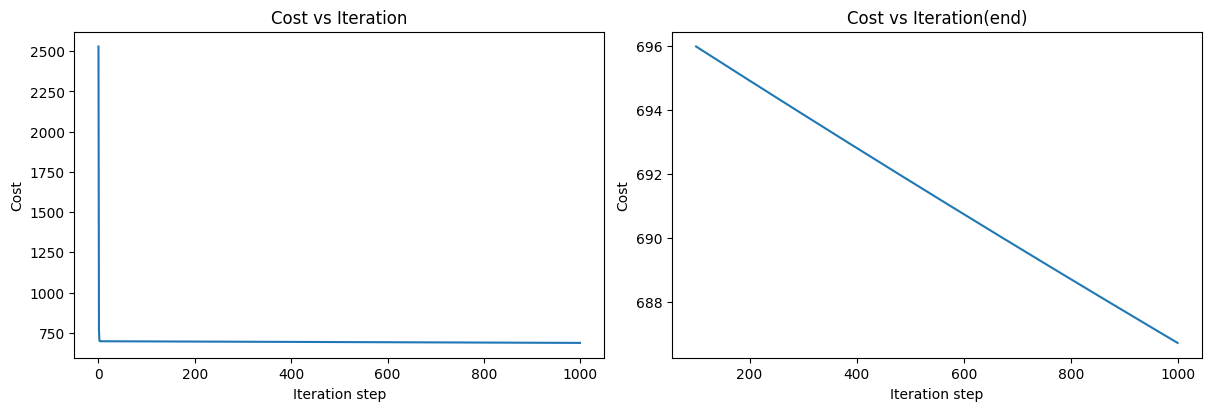

In [19]:
# Plotting cost versus iteration

fig , (ax1,ax2) = plt.subplots(1,2,constrained_layout = True , figsize= (12,4))
ax1.plot(J_hist)
ax2.plot(100 + np.arange(len(J_hist[100:])),J_hist[100:])
ax1.set_title("Cost vs Iteration")
ax2.set_title("Cost vs Iteration(end)")
ax1.set_xlabel("Iteration step")
ax2.set_xlabel("Iteration step")
ax1.set_ylabel("Cost")
ax2.set_ylabel("Cost")

plt.show()